# 区分別出願件数ヒストグラム（全体マクロ集計）

個別企業ではなく、**全企業を対象**に区分（第1〜45類）別の出願件数を集計し、ヒストグラムとして可視化するノートブック。  
対象年は単年・複数年（列挙）・範囲指定のいずれにも対応する。

In [1]:
import os

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from utils.db import get_conn, DB_CONFIG
from utils.trademark_utils import parse_filing_date, extract_classes, year_like_patterns

matplotlib.rcParams['font.family'] = 'Meiryo'  # Windows 日本語フォント
print('DB設定を読み込みました:', DB_CONFIG['host'], DB_CONFIG['dbname'])

DB設定を読み込みました: 172.18.106.203 trademark_db


---

## 1. 対象年の指定

対象年（西暦、単年/複数年/範囲）を入力してからセルを実行してください。

In [2]:
# ===== 検索条件を入力 =====
target_years = [2018, 2019, 2020]   # 例: 2020（単年） / [2018, 2019, 2020]（複数年） / range(2018, 2021)（範囲）
# ==========================

# --- 入力値の正規化 ---
if isinstance(target_years, int):
    target_years = [target_years]
elif isinstance(target_years, range):
    target_years = list(target_years)
else:
    target_years = sorted(set(target_years))

# --- 入力値の検証 ---
if not target_years:
    raise ValueError(
        'target_years が未設定です（西暦4桁の整数、またはそのリスト/rangeで入力してください）'
    )


# 表示用ラベル（連続年は範囲表記、それ以外は列挙）
def _years_label(years):
    years = sorted(years)
    if len(years) == 1:
        return f'{years[0]}年'
    if years == list(range(years[0], years[-1] + 1)):
        return f'{years[0]}〜{years[-1]}年'
    return '・'.join(f'{y}年' for y in years)


years_label = _years_label(target_years)
print(f'対象年 : {years_label}')

対象年 : 2018〜2020年


---

## 2. データ取得

企業を絞らず、対象年（LIKE で粗く絞り込み）に該当する全レコードを取得する。

In [3]:
_year_patterns = year_like_patterns(target_years)

with get_conn() as conn:
    df_raw = pd.read_sql("""
        SELECT
            "filing-date"                       AS filing_date_raw,
            "goods-and-service-name-and-code"   AS goods_and_service
        FROM trademark_db
        WHERE "goods-and-service-name-and-code"  IS NOT NULL
          AND "filing-date"                       IS NOT NULL
          AND "filing-date"                       LIKE ANY(%(patterns)s)
    """, conn, params={'patterns': _year_patterns})

if df_raw.empty:
    raise ValueError(f'{years_label} の出願データが見つかりませんでした。対象年を確認してください。')

# LIKE は年の絞り込みの粗いフィルタなので、filing_date をパースして念のため厳密に再確認
df_raw['filing_date'] = df_raw['filing_date_raw'].apply(parse_filing_date)
df_raw['filing_year'] = df_raw['filing_date'].apply(lambda d: d.year if d else None)
df_raw = df_raw[df_raw['filing_year'].isin(target_years)].copy()

if df_raw.empty:
    raise ValueError(f'{years_label} の出願データが見つかりませんでした。')

print(f'取得件数 : {len(df_raw):,} 件（{years_label}）')
df_raw.head(3)

C:\Users\k-fukuzawa\AppData\Local\Temp\ipykernel_404\1450342222.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql("""


取得件数 : 353,283 件（2018〜2020年）


,filing_date_raw,goods_and_service,filing_date,filing_year
0,平成３０年１月５日（２０１８．１．５）,第１４類 キーホルダー，貴金属製キーチェーン，宝石箱，記念カップ，記念たて，身飾品，指輪，...,2018-01-05,2018
1,平成３０年１月９日（２０１８．１．９）,第１４類 宝石箱，時計，腕時計，キーホルダー，宝玉及びその原石並びに宝玉の模造品，時計の部...,2018-01-09,2018
2,平成３０年１月５日（２０１８．１．５）,"第３類 せっけん類，歯磨き，化粧品，香料，薫料，つけづめ，つけまつ毛,第２１類 化粧用具...",2018-01-05,2018


---

## 3. 前処理・集計

`goods-and-service-name-and-code` から区分番号を抽出し、1行1区分に展開したうえで、出願年 × 区分番号ごとに件数を集計する。

In [4]:
df_raw['class_list'] = df_raw['goods_and_service'].apply(extract_classes)

n_class_empty = df_raw['class_list'].apply(len).eq(0).sum()
print(f'区分抽出ゼロ件: {n_class_empty:,} 件')

df_exploded = (
    df_raw
    .explode('class_list')
    .dropna(subset=['class_list'])
    .rename(columns={'class_list': 'class_number'})
    .astype({'class_number': int, 'filing_year': int})
)

result = (
    df_exploded
    .groupby(['filing_year', 'class_number'])
    .size()
    .reset_index(name='application_count')
    .sort_values(['filing_year', 'class_number'])
    .reset_index(drop=True)
)

print(f'{years_label}　集計行数: {len(result):,} 行')
result.head()

区分抽出ゼロ件: 0 件
2018〜2020年　集計行数: 135 行


,filing_year,class_number,application_count
0,2018,1,2565
1,2018,2,654
2,2018,3,10601
3,2018,4,522
4,2018,5,8337


---

## 4. 区分別出願件数ヒストグラム（全体・年合算）

第1類〜第45類を横軸に、指定した対象年を合算した出願件数を縦軸に表示する。出願ゼロの区分も含めて全45区分を描画する。

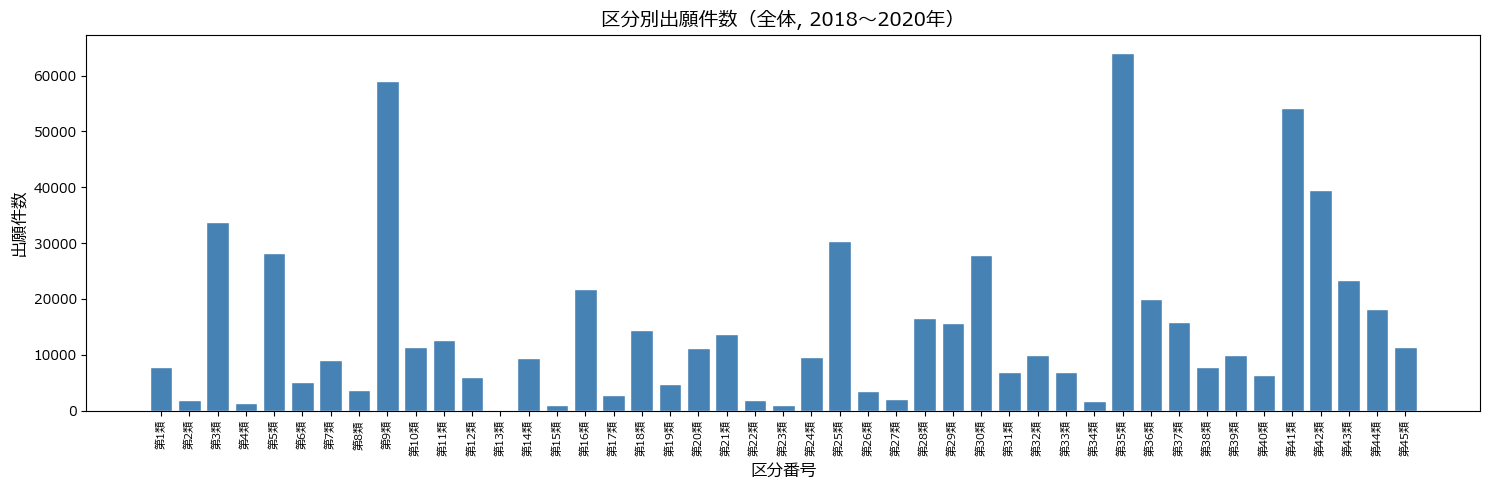

In [5]:
all_classes = range(1, 46)
hist_data = (
    result
    .groupby('class_number')['application_count'].sum()
    .reindex(all_classes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(hist_data.index, hist_data.values, color='steelblue', edgecolor='white')

ax.set_xlabel('区分番号', fontsize=12)
ax.set_ylabel('出願件数', fontsize=12)
ax.set_title(f'区分別出願件数（全体, {years_label}）', fontsize=14)
ax.set_xticks(list(all_classes))
ax.set_xticklabels([f'第{c}類' for c in all_classes], rotation=90, fontsize=8)
ax.yaxis.get_major_locator().set_params(integer=True)

plt.tight_layout()
plt.show()

---

## 5. 年別ヒストグラム（複数年指定時）

対象年が複数の場合、出願年ごとに区分別件数を並べたグラフを表示する。

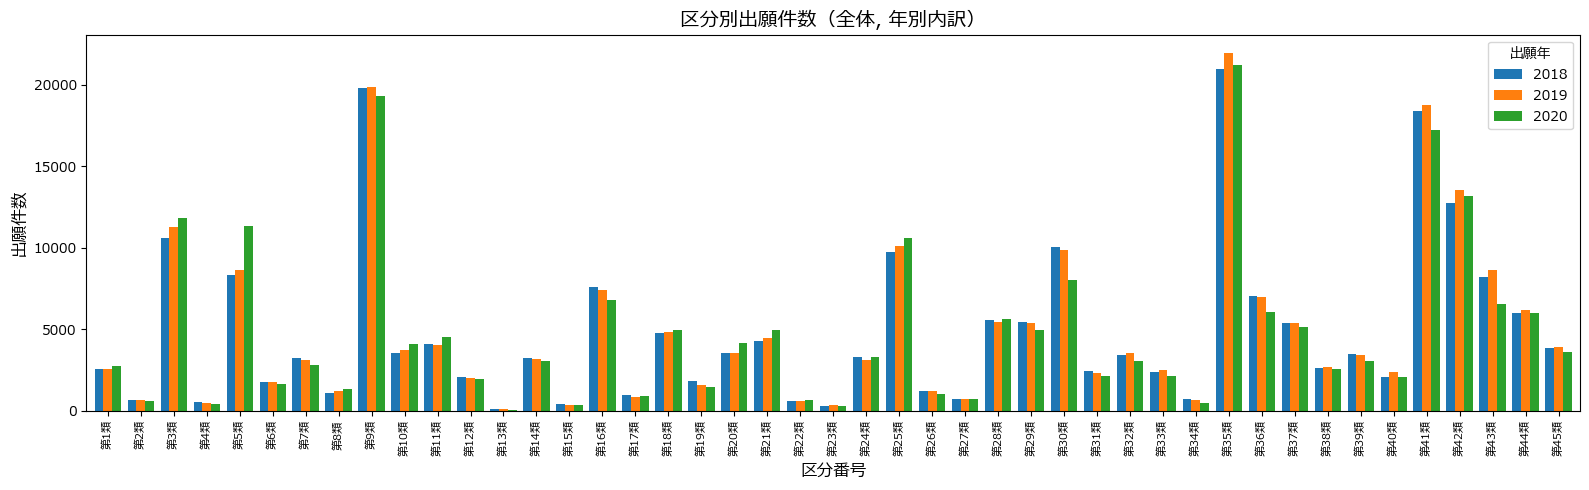

In [6]:
if len(target_years) > 1:
    pivot = (
        result
        .pivot_table(
            index='class_number',
            columns='filing_year',
            values='application_count',
            aggfunc='sum',
            fill_value=0,
        )
        .reindex(all_classes, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    pivot.plot(kind='bar', ax=ax, width=0.8)

    ax.set_xlabel('区分番号', fontsize=12)
    ax.set_ylabel('出願件数', fontsize=12)
    ax.set_title(f'区分別出願件数（全体, 年別内訳）', fontsize=14)
    ax.set_xticklabels([f'第{c}類' for c in all_classes], rotation=90, fontsize=8)
    ax.legend(title='出願年')

    plt.tight_layout()
    plt.show()
else:
    print('対象年が単年のため、年別内訳グラフは省略します。')

---

## 6. CSV 出力（任意）

In [ ]:
_year_suffix = f'{target_years[0]}' if len(target_years) == 1 else f'{target_years[0]}-{target_years[-1]}'
out_path = f'output/class_filing_overall_{_year_suffix}.csv'
os.makedirs('output', exist_ok=True)
result.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'保存しました: {out_path}')